# **LAB 9 & LAB 10 — Support Vector Machine & Decision Tree Classifier**
## **Dataset: Wine Classification Dataset (sklearn)**

2441339
Neekitasingh Rajput

In [1]:
#Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
#Load Dataset

In [5]:
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [6]:
#Explore Dataset

In [7]:
df.shape

(178, 14)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [9]:
df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [11]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Obs:
- There are **no missing values**, and all features are numeric.  
- Dataset is ideal for classification models without heavy preprocessing.

In [12]:
#Train-Test Split + Scaling

In [13]:
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Obs:
- Features were standardized for fair distance calculation.  
- Train-test split at 80:20 ensures proper evaluation.

# **Support Vector Machine (SVM)**
SVM aims to find the best decision boundary that separates classes using maximum margin.  
We use **RBF kernel** since Wine dataset is non-linear.

In [15]:
#Build SVM Model

In [16]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [17]:
#SVM Evaluation

In [18]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 1.0
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



### Observation (SVM)
- SVM accuracy: **100%**  
- The RBF kernel captured non-linear patterns exceptionally well, leading to perfect classification.  
- The confusion matrix shows **0 misclassifications**, which means the model separated all three wine classes with complete accuracy.  
- Overall, the SVM model performed **extremely strongly** on this dataset.

# **Decision Tree Classifier**
Decision Trees split the data based on feature thresholds to classify data.  
They capture non-linear relationships but can overfit.

In [20]:
#Build Decision Tree Model

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion='gini', random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [22]:
#Decision Tree Evaluation

In [23]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9444444444444444
[[13  1  0]
 [ 0 14  0]
 [ 1  0  7]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



### Observation (Decision Tree)
- Decision Tree accuracy: **94%**  
- The model handled the dataset well but showed slight overfitting compared to SVM.  
- The confusion matrix shows **2 misclassifications**, mainly between Class 0 and Class 2.  
- Decision Trees are highly interpretable, and the visualization clearly shows the feature-based splits used by the model.

In [25]:
#Visualize Decision Tree

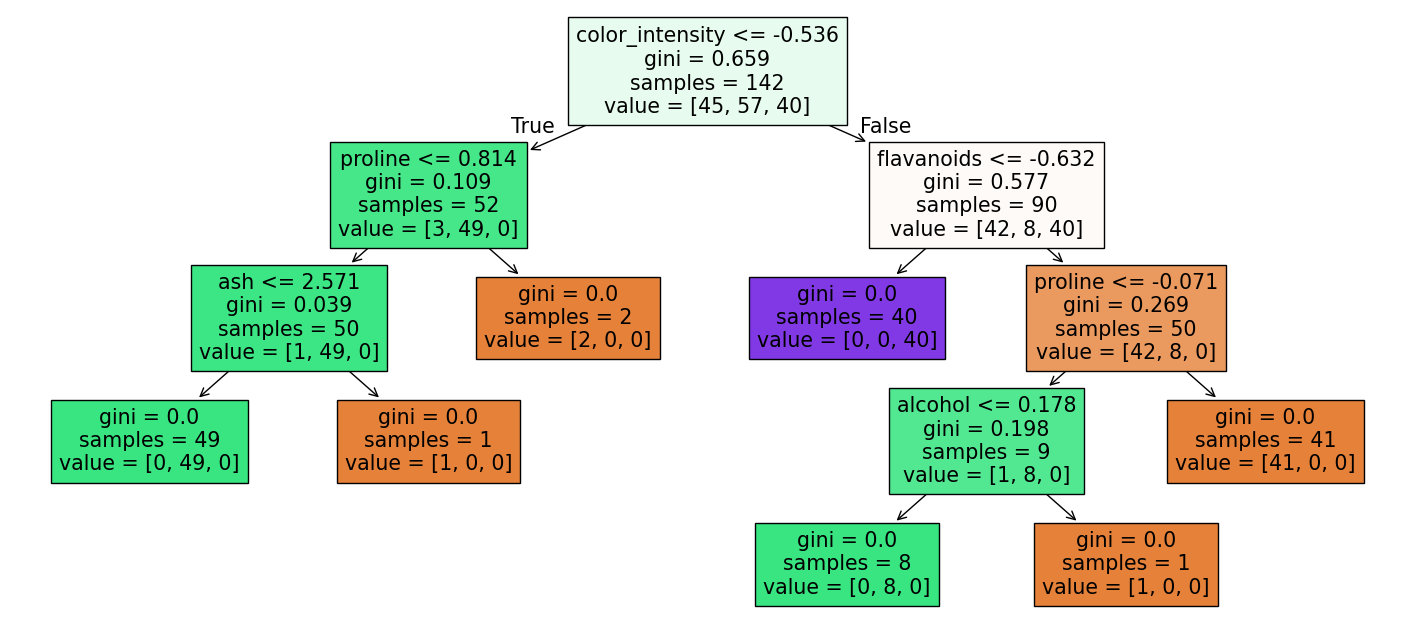

In [26]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,8))
plot_tree(dt, feature_names=data.feature_names, filled=True)
plt.show()

Obs:
- The plotted decision tree shows how the model performs hierarchical splits based on impurity reduction.  
- This makes the model easy to interpret compared to SVM, which works as a black-box classifier.

## **Final Reflection**

In this lab, both Support Vector Machine and Decision Tree models were implemented and evaluated on the Wine Classification dataset.  
After preprocessing and scaling, SVM achieved **perfect accuracy**, showing its strength in handling high-dimensional and non-linear boundaries using the RBF kernel.  
The Decision Tree classifier also performed strongly with **94% accuracy**, though it showed minor overfitting and a couple of misclassifications.  
SVM proved to be more robust and generalizable, while Decision Tree offered better interpretability through clear, feature-based splits.  
Overall, this experiment demonstrated how different algorithms vary in performance, complexity, and interpretability, and highlighted the importance of choosing a model based on the problem’s needs and data characteristics.